In [16]:
!git clone https://github.com/hriday-goyal/ozone-ai-ml.git

fatal: destination path 'ozone-ai-ml' already exists and is not an empty directory.


# Smart Controller for Safe Ozone Generation
This notebook uses classification models to determine whether ozone generator usage is safe based on room size, voltage, runtime, and environmental conditions.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [18]:
# Load dataset
df = pd.read_csv('/content/ozone-ai-ml/data/simulated_ozone_data.csv')
df.head()

,Voltage_kV,Time_min,Gap_mm,Temperature_C,Humidity_percent,Ozone_ppm
0,5.621781,19.618918,1.412495,22.534026,65.361932,36.821559
1,9.655000,3.440059,4.610212,24.178855,37.626952,6.276422
2,8.123958,5.687233,3.021009,22.655157,58.814418,10.062225
3,7.190609,27.058071,4.305830,21.330538,60.335752,30.588849
4,4.092130,18.586443,2.280198,21.809538,51.206534,21.557559


In [19]:
# Add room volume (fixed small room or user input simulation)
df['Room_Volume_cuft'] = 1.6  # based on 13x12x12 inch box converted to cubic feet

In [20]:
# Define a synthetic classification threshold for demonstration
# This is NOT a real-world safety limit.

SAFE_THRESHOLD_PPM = df['Ozone_ppm'].median()

df['Safe'] = df['Ozone_ppm'].apply(
    lambda x: 1 if x <= SAFE_THRESHOLD_PPM else 0
)

print("Synthetic threshold:", SAFE_THRESHOLD_PPM)
print("\nClass distribution:")
print(df['Safe'].value_counts())

# 1 = Below the synthetic threshold
# 0 = Above the synthetic threshold

Synthetic threshold: 20.78384638602487

Class distribution:
Safe
0    100
1    100
Name: count, dtype: int64


In [21]:
print(df['Safe'].value_counts())

Safe
0    100
1    100
Name: count, dtype: int64


In [22]:
# Split features and labels
X = df[['Voltage_kV', 'Time_min', 'Gap_mm', 'Temperature_C', 'Humidity_percent', 'Room_Volume_cuft']]
y = df['Safe']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# Logistic Regression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred_log = logreg.predict(X_test)
print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        17

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [24]:
# Random Forest Classifier
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)
y_pred_rf = rfc.predict(X_test)
print('Random Forest Accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        23
           1       0.88      0.88      0.88        17

    accuracy                           0.90        40
   macro avg       0.90      0.90      0.90        40
weighted avg       0.90      0.90      0.90        40



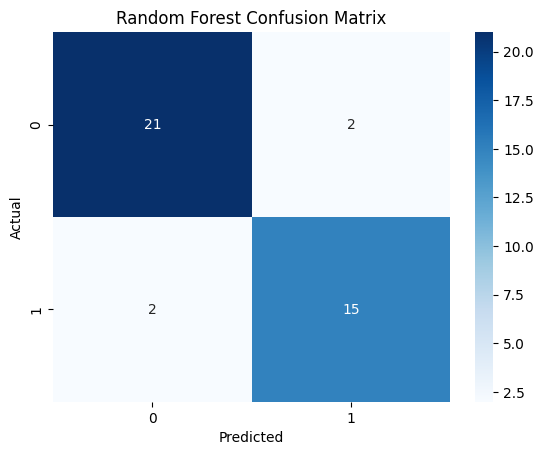

In [25]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()